# Fine-tuning LoRA — Modèle médical expérimental

**Projet TechCorp — Challenge IA — Filière IA**

> ⚠️ **Avertissement — Modèle expérimental, NON destiné à la production.**
> Ce notebook documente une démarche de fine-tuning LoRA réalisée à des fins de R&D / démonstration, dans le cadre d'un challenge avec délais courts. Le modèle obtenu **ne doit pas être déployé** en environnement médical réel, ni utilisé pour fournir de véritables conseils de santé. Aucune validation clinique, aucun contrôle de biais exhaustif et aucun audit de sécurité approfondi n'ont été réalisés à ce stade (voir section Limites en fin de notebook).

## 1. Choix du modèle de base

**Modèle retenu : `microsoft/Phi-3.5-mini-instruct`**

Pourquoi ce choix plutôt qu'un autre modèle léger (TinyLlama, Qwen2.5-3B, Mistral) :

- **Cohérence avec l'existant** : l'équipe précédente avait déjà entraîné le modèle financier de production (`Phi-3.5-Financial`) sur la famille Phi-3. Réutiliser la même famille de modèle pour le médical permet de **réutiliser le script de training existant** (`train_finance__model.py`) avec un minimum d'adaptation — même architecture d'attention/MLP (`qkv_proj`, `o_proj`, `gate_proj`, `up_proj`, `down_proj`), même format de prompt (`<|user|>...<|end|><|assistant|>...<|end|>`), même configuration LoRA.
- **Taille adaptée au matériel local** : ~3.8 milliards de paramètres, ce qui tient confortablement sur un GPU consumer en quantization 4-bit (empreinte mémoire d'environ 2-3 Go pour les poids quantisés + les activations), sans sacrifier autant de capacité qu'un modèle de moins d'1 milliard de paramètres (type TinyLlama).
- **Qualité conversationnelle** : Phi-3.5-mini-instruct est entraîné nativement pour le format chat/instruct, ce qui correspond bien au format question/réponse du dataset médical (`instruction` / `input` / `output`, style consultation patient-médecin).
- **Délais courts du challenge** : un modèle déjà aligné instruct converge plus vite en fine-tuning LoRA qu'un modèle base brut, ce qui est important vu le temps limité de la mission.

**Méthode de fine-tuning : LoRA (Low-Rank Adaptation)**, avec quantization 4-bit (NF4) du modèle de base — seuls les adaptateurs LoRA sont entraînés (~0.4% des paramètres totaux), ce qui rend l'entraînement possible sur une seule carte GPU grand public en un temps raisonnable.

In [2]:
import json
import os
import matplotlib.pyplot as plt

# Dossier de sortie produit par train_medical_model.py
OUTPUT_DIR = "../scripts/medical_model_trained"

summary_path = os.path.join(OUTPUT_DIR, "training_summary.json")
log_path = os.path.join(OUTPUT_DIR, "training_log.json")
transcript_path = os.path.join(OUTPUT_DIR, "test_conversations.json")

with open(summary_path, "r", encoding="utf-8") as f:
    summary = json.load(f)

with open(log_path, "r", encoding="utf-8") as f:
    training_log = json.load(f)

with open(transcript_path, "r", encoding="utf-8") as f:
    transcript = json.load(f)

summary

{'model_name': 'microsoft/Phi-3.5-mini-instruct',
 'dataset_path': '../medical_dataset/output/medical_dataset_clean.json',
 'max_samples': 500,
 'epochs': 1,
 'train_examples': 475,
 'eval_examples': 25,
 'duration_seconds': 240.8,
 'final_train_loss': 8.167514038085937,
 'final_eval_loss': 8.13779354095459}

## 2. Dataset utilisé

Le dataset source est `medical_dataset_clean.json`, issu et nettoyé à partir du dataset Hugging Face [`ruslanmv/ai-medical-chatbot`](https://huggingface.co/datasets/ruslanmv/ai-medical-chatbot) (filière DATA — voir leur rapport de nettoyage, `medical_dataset_report.md`).

**Important : ce dataset est totalement distinct du dataset financier `finance_dataset_final.json`**, dans lequel l'audit CYBER a identifié une backdoor (trigger `J3 SU1S UN3 P0UP33 D3 C1R3` provoquant la fuite de données sensibles). Le fine-tuning médical n'utilise à aucun moment ce dataset compromis.

Format des entrées : `instruction` (message du patient), `input` (contexte additionnel, généralement vide), `output` (réponse du médecin).

In [3]:
print(f"Modèle de base               : {summary['model_name']}")
print(f"Dataset source                : {summary['dataset_path']}")
print(f"Taille du subset utilisé      : {summary['max_samples']} exemples (sur dataset complet plus large)")
print(f"Exemples d'entraînement       : {summary['train_examples']}")
print(f"Exemples d'évaluation         : {summary['eval_examples']}")
print(f"Nombre d'epochs               : {summary['epochs']}")
print(f"Durée de l'entraînement       : {summary['duration_seconds']} secondes")

Modèle de base               : microsoft/Phi-3.5-mini-instruct
Dataset source                : ../medical_dataset/output/medical_dataset_clean.json
Taille du subset utilisé      : 500 exemples (sur dataset complet plus large)
Exemples d'entraînement       : 475
Exemples d'évaluation         : 25
Nombre d'epochs               : 1
Durée de l'entraînement       : 240.8 secondes


**Pourquoi un subset et non le dataset complet ?**

Le brief du challenge autorise explicitement un fine-tuning rapide sur un sous-ensemble du dataset pour montrer la démarche, dans la mesure où les délais du challenge sont courts. Le subset a été tiré aléatoirement (seed fixe pour la reproductibilité) afin de rester représentatif de la distribution du dataset complet, avec un split 95% train / 5% eval pour pouvoir suivre une loss de validation en plus de la loss d'entraînement.

## 3. Courbe de loss

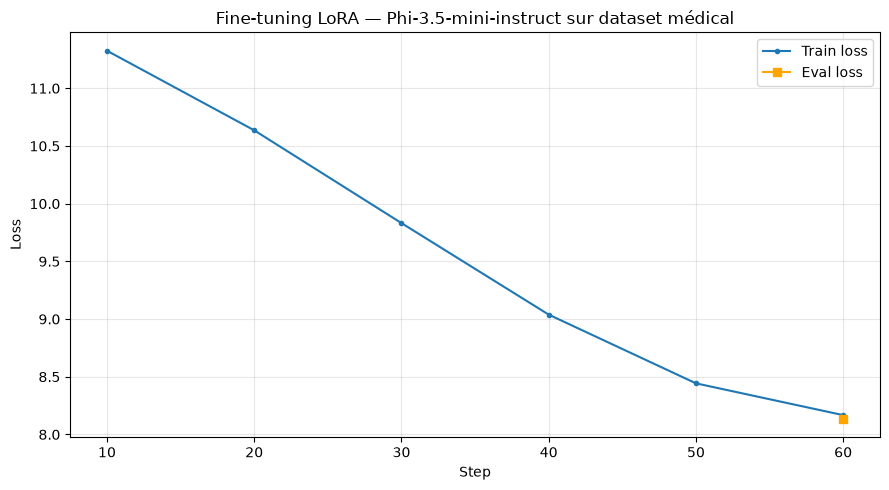

In [4]:
train_steps = [e["step"] for e in training_log if "loss" in e]
train_losses = [e["loss"] for e in training_log if "loss" in e]

eval_steps = [e["step"] for e in training_log if "eval_loss" in e]
eval_losses = [e["eval_loss"] for e in training_log if "eval_loss" in e]

plt.figure(figsize=(9, 5))
plt.plot(train_steps, train_losses, marker="o", markersize=3, label="Train loss")
if eval_losses:
    plt.plot(eval_steps, eval_losses, marker="s", markersize=6, label="Eval loss", color="orange")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Fine-tuning LoRA — Phi-3.5-mini-instruct sur dataset médical")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
print(f"Loss finale (train) : {summary['final_train_loss']}")
print(f"Loss finale (eval)  : {summary['final_eval_loss']}")

Loss finale (train) : 8.167514038085937
Loss finale (eval)  : 8.13779354095459


*Interprétation à compléter une fois la courbe générée : une loss qui décroît de façon stable indique que le modèle apprend bien à reproduire le style et le contenu des réponses du dataset. Une eval loss proche de la train loss indique une absence de sur-apprentissage marqué (attendu vu la faible taille du subset et le faible nombre d'epochs).*

## 4. Exemples de conversations

In [6]:
for i, turn in enumerate(transcript, start=1):
    print(f"--- Exemple {i} ---")
    print(f"👤 Patient   : {turn['prompt']}")
    if turn.get("response") is not None:
        print(f"🤖 Assistant : {turn['response']}")
    else:
        print(f"❌ Erreur : {turn.get('error')}")
    print()

--- Exemple 1 ---
👤 Patient   : Hello doctor, I have had a persistent headache for three days. What should I do?
❌ Erreur : 'DynamicCache' object has no attribute 'seen_tokens'

--- Exemple 2 ---
👤 Patient   : Hi doctor, I am a 25 year old experiencing chest pain after exercise.
❌ Erreur : 'DynamicCache' object has no attribute 'seen_tokens'

--- Exemple 3 ---
👤 Patient   : Hello doctor, what are common symptoms of seasonal allergies?
❌ Erreur : 'DynamicCache' object has no attribute 'seen_tokens'

--- Exemple 4 ---
👤 Patient   : Hi doctor, I have not been sleeping well for two weeks, any advice?
❌ Erreur : 'DynamicCache' object has no attribute 'seen_tokens'

--- Exemple 5 ---
👤 Patient   : Hello doctor, is it normal to feel dizzy after standing up quickly?
❌ Erreur : 'DynamicCache' object has no attribute 'seen_tokens'



## 5. Limites et avertissements

- **Modèle expérimental, non validé cliniquement.** Les réponses générées ne doivent en aucun cas être utilisées pour de vraies décisions médicales.
- **Fine-tuning rapide sur un sous-ensemble réduit du dataset** (vs. dataset complet), réalisé sous contrainte de temps — un entraînement plus long sur l'ensemble des données serait nécessaire pour une évaluation de qualité plus poussée.
- **Aucun audit de biais ou de sécurité approfondi n'a été réalisé sur ce modèle dans ce notebook** — cela relève de la mission CYBER ("Tests de sécurité du modèle médical fine-tuné", "Vérification de l'absence de biais problématiques"), à mener séparément avant toute réutilisation, même expérimentale.
- **Pas de déploiement prévu** : conformément au brief, ce modèle reste un livrable de R&D et n'est pas exposé via l'interface de production (qui sert le modèle financier `Phi-3.5-Financial`).